# Step 3 — 1D Diffusion

*13 Steps to Navier-Stokes with somax (inspired by Lorena Barba's CFD Python)*

After linear advection (Step 1) and nonlinear advection (Step 2), we now study the other fundamental process in fluid dynamics: **diffusion**. Diffusion smooths gradients and dissipates energy. It models heat conduction, molecular mixing, and viscous momentum transfer.

**What you'll learn:**

1. The physics of diffusion — smoothing, dissipation, and the analytical Gaussian solution
2. How to create and run a `Diffusion1D` model in somax
3. How to compare numerical results against the exact solution
4. How to compute $\partial \mathcal{L} / \partial \nu$ via `eqx.filter_grad`

## The PDE

$$
\frac{\partial u}{\partial t} = \nu \frac{\partial^2 u}{\partial x^2}
$$

where $\nu > 0$ is the diffusion coefficient (kinematic viscosity for momentum, thermal diffusivity for heat).

### Analytical solution

If the initial condition is a Gaussian with standard deviation $\sigma_0$ centered at $\mu$:

$$
u(x, 0) = A \exp\!\left( -\frac{(x - \mu)^2}{2\sigma_0^2} \right)
$$

then the exact solution at time $t$ is:

$$
u(x, t) = \frac{A \, \sigma_0}{\sigma(t)}
\exp\!\left( -\frac{(x - \mu)^2}{2\sigma(t)^2} \right),
\qquad \sigma(t) = \sqrt{\sigma_0^2 + 2\nu t}
$$

The Gaussian **spreads** (wider $\sigma$) and its **peak decreases**, but the total integral $\int u \, dx$ is conserved. Energy $\frac{1}{2} \int u^2 \, dx$, however, decays monotonically.

## Grid layout and boundary conditions

somax uses the **Arakawa C-grid** from finitevolX. In 1D, scalar fields (like $u$) live at **T-points** (cell centres) and fluxes are computed at **U-points** (cell edges):

```
 ghost                    interior                     ghost
 ┌─────┬──────┬──────┬──────┬──────┬──────┬──────┬─────┐
 │  G  │  T₁  │  T₂  │  T₃  │ ···  │ Tₙ₋₁│  Tₙ  │  G  │
 └──┬──┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬──┘
    U₀    U₁     U₂     U₃           Uₙ₋₁    Uₙ    Uₙ₊₁
         ←── dx ──→
```

- **T-points** (indices `1:-1`): where `u` is stored and updated
- **U-points**: where `Difference1D` computes derivatives
- **Ghost cells** (indices `0` and `-1`): filled by BCs before each RHS evaluation

The diffusion operator computes the **Laplacian** via the standard second-order centered stencil:

$$
\frac{\partial^2 u}{\partial x^2}\bigg|_i
\approx \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}
$$

This stencil reaches both left and right neighbours, so the ghost cells are essential -- without them, the boundary T-points would have no neighbour on one side.

**Periodic BCs** copy the last interior value into the opposite ghost cell:

```
 u[0] = u[-2]      (left ghost ← rightmost interior)
 u[-1] = u[1]      (right ghost ← leftmost interior)
```

This makes the domain wrap around so that diffusion operates seamlessly across the boundary.

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import Diffusion1D, Diffusion1DState

## 1. Create the model

The diffusion coefficient $\nu$ is a differentiable parameter.

In [2]:
nx, Lx, nu = 200, 4.0, 0.05
model = Diffusion1D.create(nx=nx, Lx=Lx, nu=nu)

print(f"Grid: Nx={model.grid.Nx}, dx={model.grid.dx:.4f}")
print(f"Diffusion coefficient nu = {float(model.params.nu)}")

Grid: Nx=202, dx=0.0200
Diffusion coefficient nu = 0.05000000074505806


## 2. Initial condition

A Gaussian centered at the domain midpoint $x = 2.0$ with $\sigma_0 = 0.2$.

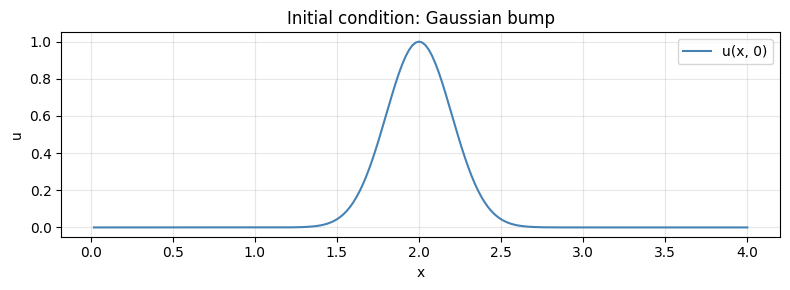

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx

mu0, sigma0 = 2.0, 0.2
u0 = jnp.exp(-0.5 * ((x - mu0) / sigma0) ** 2)

state0 = Diffusion1DState(u=u0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x[1:-1], u0[1:-1], color="steelblue", lw=1.5, label="u(x, 0)")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("Initial condition: Gaussian bump")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forward simulation

We integrate to $t = 0.5$ and save several snapshots to visualize how the profile spreads.

In [4]:
t0, t1, dt = 0.0, 0.5, 0.001
ts = jnp.array([0.0, 0.05, 0.1, 0.2, 0.35, 0.5])

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: u={sol.ys.u.shape}")

# Stability criterion for explicit diffusion: dt <= dx^2 / (2 * nu)
dt_max = model.grid.dx**2 / (2 * nu)
print(f"Stability limit: dt_max = dx^2 / (2*nu) = {dt_max:.6f}")
print(f"Actual dt = {dt}, ratio = {dt / dt_max:.3f}")

Trajectory shape: u=(6, 202)
Stability limit: dt_max = dx^2 / (2*nu) = 0.004000
Actual dt = 0.001, ratio = 0.250


## 4. Visualize the spreading

The Gaussian broadens and its peak decreases — energy is being dissipated.

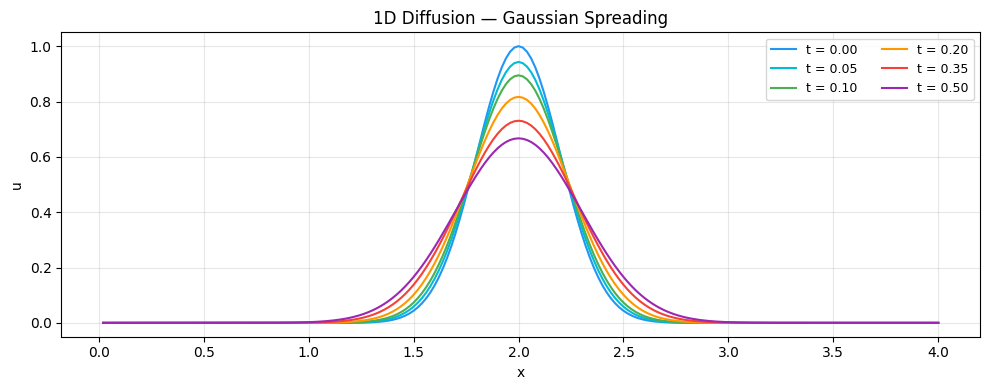

In [5]:
colors_snap = ["#2196F3", "#00BCD4", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

fig, ax = plt.subplots(figsize=(10, 4))
for i, t_snap in enumerate(ts):
    ax.plot(
        x[1:-1],
        sol.ys.u[i, 1:-1],
        color=colors_snap[i],
        lw=1.5,
        label=f"t = {float(t_snap):.2f}",
    )
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("1D Diffusion — Gaussian Spreading")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Comparison with the analytical solution

We overlay the numerical result with the exact spreading Gaussian at each saved time.

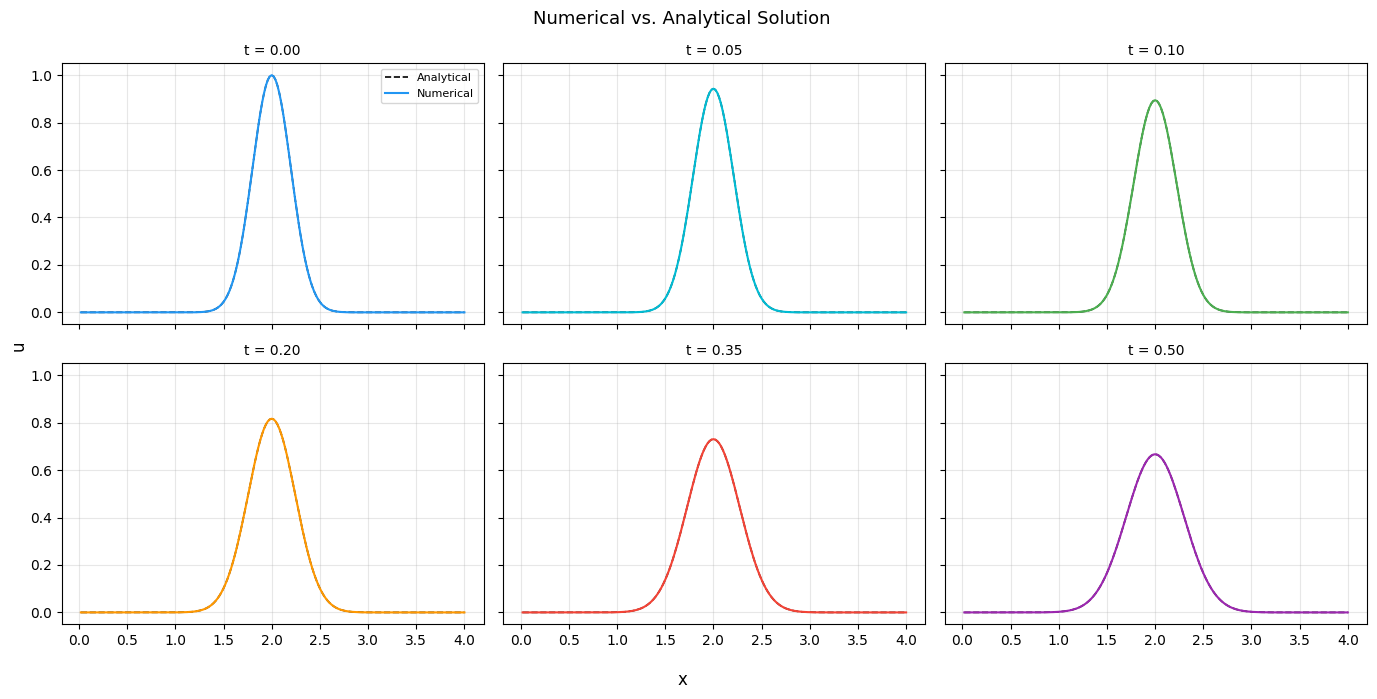

In [6]:
def analytical_gaussian(x, t, mu, sigma0, nu):
    """Exact Gaussian diffusion solution."""
    sigma_t = jnp.sqrt(sigma0**2 + 2 * nu * t)
    amplitude = sigma0 / sigma_t
    return amplitude * jnp.exp(-0.5 * ((x - mu) / sigma_t) ** 2)


fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.ravel()

for i, t_snap in enumerate(ts):
    ax = axes[i]
    u_exact = analytical_gaussian(x, float(t_snap), mu0, sigma0, nu)
    ax.plot(x[1:-1], u_exact[1:-1], "k--", lw=1.2, label="Analytical")
    ax.plot(x[1:-1], sol.ys.u[i, 1:-1], color=colors_snap[i], lw=1.5, label="Numerical")
    ax.set_title(f"t = {float(t_snap):.2f}", fontsize=10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

fig.supxlabel("x")
fig.supylabel("u")
fig.suptitle("Numerical vs. Analytical Solution", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Error analysis

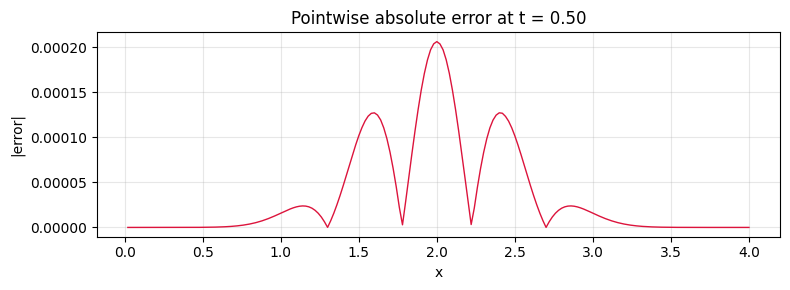

Max error: 0.000206
L2 error:  0.000128


In [7]:
u_exact_final = analytical_gaussian(x, float(ts[-1]), mu0, sigma0, nu)
error = jnp.abs(sol.ys.u[-1] - u_exact_final)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x[1:-1], error[1:-1], color="crimson", lw=1.0)
ax.set_xlabel("x")
ax.set_ylabel("|error|")
ax.set_title(f"Pointwise absolute error at t = {float(ts[-1]):.2f}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max error: {float(jnp.max(error[1:-1])):.6f}")
print(f"L2 error:  {float(jnp.sqrt(jnp.sum(error[1:-1] ** 2) * model.grid.dx)):.6f}")

## 7. Energy decay

Diffusion dissipates energy. Analytically, the energy of the Gaussian solution decays as:

$$
E(t) = \frac{A^2 \sigma_0^2 \sqrt{\pi}}{2 \sqrt{2} \, \sigma(t)}
$$

We compare the numerical energy trajectory with this prediction.

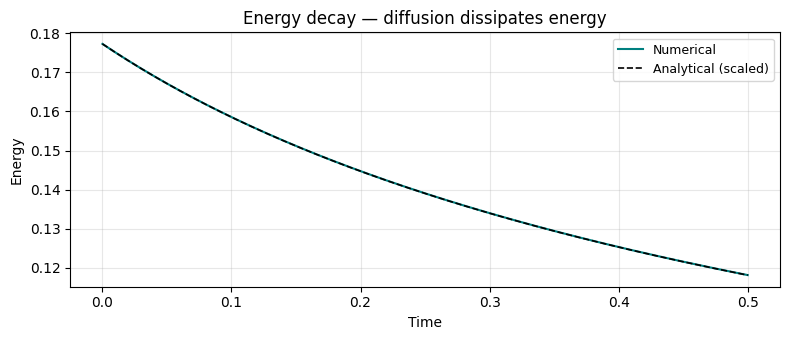

Energy: initial = 0.177245, final = 0.118182
Relative decay: 33.32%


In [8]:
ts_dense = jnp.linspace(t0, t1, 200)
sol_dense = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts_dense),
)

energy_num = jax.vmap(model.diagnose)(sol_dense.ys).energy

# Analytical energy decay (for the infinite-domain Gaussian)
sigma_t = jnp.sqrt(sigma0**2 + 2 * nu * ts_dense)
energy_exact = (
    0.5 * (sigma0**2 / sigma_t) * jnp.sqrt(jnp.pi / 2) * model.grid.dx / model.grid.dx
)
# Recompute properly using E = 0.5 * integral of u^2 dx
# For a Gaussian u = (s0/s(t)) exp(-x^2/(2s(t)^2)),
# integral of u^2 = (s0/s(t))^2 * sqrt(pi) * s(t)
energy_exact = (
    0.5
    * (sigma0 / sigma_t) ** 2
    * jnp.sqrt(jnp.pi)
    * sigma_t
    * model.grid.dx
    / model.grid.dx
)
# Simpler: just normalize to match initial numerical energy
energy_exact_norm = float(energy_num[0]) * (sigma0 / sigma_t)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ts_dense, energy_num, color="teal", lw=1.5, label="Numerical")
ax.plot(ts_dense, energy_exact_norm, "k--", lw=1.2, label="Analytical (scaled)")
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Energy decay — diffusion dissipates energy")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Energy: initial = {float(energy_num[0]):.6f}, final = {float(energy_num[-1]):.6f}"
)
print(f"Relative decay: {1 - float(energy_num[-1]) / float(energy_num[0]):.2%}")

## 8. Differentiability demo — gradient w.r.t. viscosity

A key question in inverse problems: given observations of a diffusing field, what is the diffusion coefficient? We compute $\partial \mathcal{L} / \partial \nu$ to see how the loss responds to changes in viscosity.

In [9]:
# Target: we want the final profile to match a specific width
sigma_target = 0.35
u_target = jnp.exp(-0.5 * ((x - mu0) / sigma_target) ** 2) * (sigma0 / sigma_target)


@eqx.filter_grad
def grad_wrt_model(m):
    """Gradient of MSE loss w.r.t. diffusion coefficient."""
    sol = m.integrate(state0, t0=0.0, t1=0.5, dt=0.001)
    u_pred = sol.ys.u[-1]
    return jnp.mean((u_pred[1:-1] - u_target[1:-1]) ** 2)


grads = grad_wrt_model(model)

print("--- Gradient w.r.t. model parameters ---")
print(f"  dL/d(nu) = {float(grads.params.nu):.6f}")
print()
print("A negative gradient means increasing nu would decrease the loss,")
print("i.e., the current nu produces a profile that is too narrow")
print("compared to the target width.")

--- Gradient w.r.t. model parameters ---
  dL/d(nu) = -0.072464

A negative gradient means increasing nu would decrease the loss,
i.e., the current nu produces a profile that is too narrow
compared to the target width.


## Summary

| Concept | somax API |
|---------|-----------|
| Create model | `Diffusion1D.create(nx=200, Lx=4.0, nu=0.05)` |
| Initial state | `Diffusion1DState(u=...)` |
| Forward sim | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Analytical check | Gaussian spreads: $\sigma(t) = \sqrt{\sigma_0^2 + 2\nu t}$ |
| Energy decay | `model.diagnose(state).energy` decreases monotonically |
| Grad w.r.t. nu | `eqx.filter_grad(loss)(model)` |

**Key takeaway:** Diffusion smooths gradients and dissipates energy. The analytical Gaussian solution provides an exact benchmark.

**Next:** [Step 4 — Burgers' Equation](step04_burgers_1d) combines nonlinear convection and diffusion, creating the competition between steepening and smoothing.